In [1]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout,
    Input
)

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [1]:
import numpy as np

X_train = np.load(r"E:\Hybrid_IDS_Project\dataset\processed\x_train_scaled.npy")
X_test = np.load(r"E:\Hybrid_IDS_Project\dataset\processed\x_test_scaled.npy")

y_train = np.load(r"E:\Hybrid_IDS_Project\dataset\processed\y_train.npy")
y_test = np.load(r"E:\Hybrid_IDS_Project\dataset\processed\y_test.npy")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2016638, 78)
X_test : (504160, 78)
y_train: (2016638,)
y_test : (504160,)


In [2]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train.shape)
print(X_test.shape)

(2016638, 78, 1)
(504160, 78, 1)


In [3]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout
)

In [4]:
cnn = Sequential([

    Input(shape=(78,1)),

    Conv1D(
        filters=32,
        kernel_size=3,
        activation='relu'
    ),

    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    ),

    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

In [5]:
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [6]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 76, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 38, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 36, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 18, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,241 (633.75 KB)

 Trainable params: 162,241 (633.75 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weight_dict)

{0: np.float64(0.6016061621257186), 1: np.float64(2.9604806910300563)}


In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    r"E:\Hybrid_IDS_Project\dataset\models\cnn.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [9]:
history = cnn.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=1024,
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/20
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9588 - loss: 0.0888 - val_accuracy: 0.9736 - val_loss: 0.0551
Epoch 2/20
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9707 - loss: 0.0549 - val_accuracy: 0.9732 - val_loss: 0.0473
Epoch 3/20
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9732 - loss: 0.0491 - val_accuracy: 0.9734 - val_loss: 0.0520
Epoch 4/20
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9762 - loss: 0.0445 - val_accuracy: 0.9786 - val_loss: 0.0428
Epoch 5/20
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9785 - loss: 0.0406 - val_accuracy: 0.9817 - val_loss: 0.0375
Epoch 6/20
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9798 - loss: 0.0377 - val_accuracy: 0.9805 - val_loss: 0.0399
Epoch 7/20
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9807 - loss: 0.0350 - val_accuracy: 0.9787 - val_loss: 0.0409
Epoch 8/20
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9812 -

In [10]:
y_pred_prob = cnn.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

15755/15755 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step


In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=["BENIGN", "ATTACK"]
))

Accuracy : 0.9844136781973977
Precision: 0.9210795850767085
Recall   : 0.9927772819091464
F1-score : 0.9555854491193959

Classification Report
              precision    recall  f1-score   support

      BENIGN       1.00      0.98      0.99    419012
      ATTACK       0.92      0.99      0.96     85148

    accuracy                           0.98    504160
   macro avg       0.96      0.99      0.97    504160
weighted avg       0.99      0.98      0.98    504160



In [12]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

fpr = fp / (fp + tn)

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print("False Positive Rate:", fpr)

TN: 411769
FP: 7243
FN: 615
TP: 84533
False Positive Rate: 0.017285901119777


In [13]:
import pandas as pd

results = pd.read_csv(
    r"E:\Hybrid_IDS_Project\dataset\results\model_results.csv"
)

cnn_result = pd.DataFrame({
    "Model": ["CNN"],
    "Experiment": ["Known Attack - Binary"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "FPR": [fpr],
    "TN": [tn],
    "FP": [fp],
    "FN": [fn],
    "TP": [tp]
})

results = pd.concat([results, cnn_result], ignore_index=True)

results.to_csv(
    r"E:\Hybrid_IDS_Project\dataset\results\model_results.csv",
    index=False
)

results

,Model,Experiment,Accuracy,Precision,Recall,F1_Score,FPR,TN,FP,FN,TP
0,Random Forest,Known Attack - Binary,0.998929,0.994483,0.999201,0.996837,0.001126,418540,472,68,85080
1,CNN,Known Attack - Binary,0.984414,0.921080,0.992777,0.955585,0.017286,411769,7243,615,84533


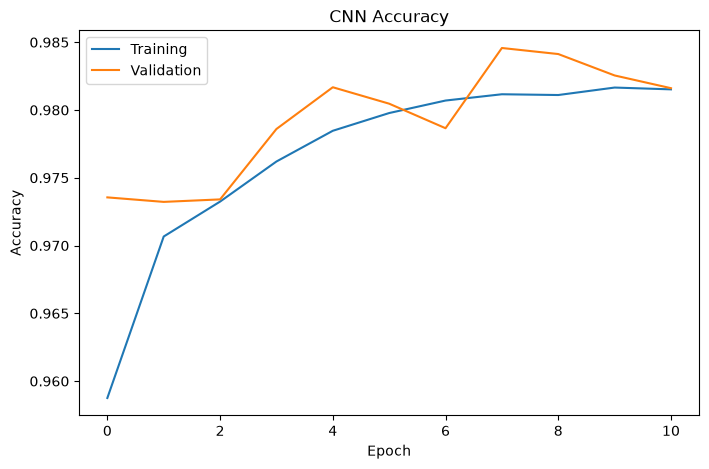

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig(
    r"E:\Hybrid_IDS_Project\dataset\figures\cnn_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()